# Bepaling van soortelijke warmte van water


# Introductie

Water heeft een enorme buffercapaciteit: je moet veel energie toevoegen om de temperatuur van water een graad te verwarmen. In dit practicum gaan we de soortelijke warmte van water bepalen door een bekende hoeveelheid water te verwarmen met een bekende hoeveelheid energie, en de temperatuurstijging te meten.

# Theorie

Geef hier de natuurkundige achtergrond van het onderwerp. 

# Methode en materialen

## Ontwerp
Een waterbad met bekende massa aan water wordt verwarmd met een elektrisch verwarmingselement dat een bekende hoeveelheid energie levert.
De temperatuur van het water wordt gemeten met een temperatuursensor.
Door de temperatuurstijging als functie van de tijd te meten kan de soortelijke warmte van water worden berekend.


## Materialen
Hieronder staat de lijst van benodigde materialen bij deze proef:
- Maatbeker
- Weegschaal
- Water
- Elektrisch verwarmingselement ($10 \mathrm{\Omega}$, $10 \mathrm{W}$)
- Voedingsbron 
- Thermometer of temperatuursensor
- Stopwatch of timer

```{figure} figures/cwater_setup.jpg
:width: 70%

Een schematische weergave van de opstelling
```

## Procedure
Voorbereiding
1. Weeg de lege maatbeker.
2. Vul deze met een hoeveelheid water en bepaal de massa van het water.
3. Plaats de thermometer in het water.
4. Plaats het verwarmingselement volledig in het water.

Instellen van de meting
1. Noteer de beginseltemperatuur van het water.
2. Controleer of de roerder aanstaat.
3. Stel de voedingsbron in op de gewenste spanning (zodat het vermogen onder de 40 W blijft).

Uitvoeren van de meting
1. Zet de timer aan.
2. Zet de spanning aan en start gelijktijdig met temperatuurmeten.
3. Registreer de temperatuur bijvoorbeeld elke 10 seconden.
4. Ga door totdat de temperatuur minimaal 10 °C gestegen is of tot een door het team afgesproken tijd.
5. Schakel de stroom uit voordat het element uit het water wordt gehaald.

Na afloop
1. Laat het element afkoelen in water voordat je het aanraakt.
2. Verwerk de data volgens de data-analysemethode.

## Veligheid
We maken gebruik van een $10 \mathrm{\Omega}$, $10 \mathrm{W}$ weerstand.
Deze wordt snel heet.
De bronspanning mag dan ook alleen aan wanneer de weerstand in het water zit.
Raak de weerstand niet aan tijdens het experiment.
Omdat de weerstand in het water zit, kunnen we wel het elektrisch vermogen hoger zetten zonder dat de weerstand oververhit raakt.
Het maximaal vermogen mag $40 \mathrm{W}$ zijn.
Daarbij moet de roerder wel aanstaan om de warmte goed te verdelen.

## Data analyse
1. Bepaal het elektrische vermogen: P = U^2/R
2. Bepaal de temperatuurstijging uit de grafiek:
    2.1. Pas een lineaire fit toe op het lineaire gedeelte van de T(t)-grafiek
    2.2. Bepaal ΔT na een gekozen tijdsduur t
3. Bereken de soortelijke warmte van water: c = (P*t)/(m*ΔT)
```

# Resultaten


Slope a: 0.011220161290322328 K/s
Intercept b: 293.31556451612903 K
De soortelijke warmte van water is:  4278.013368791874 J/kg*K


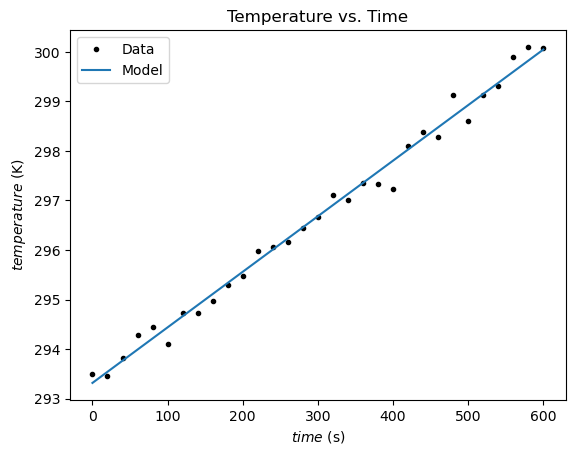

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

U = 12 # volt
R = 10  # ohm
P = U**2/R # watt
m = 0.3 # kg

data = np.loadtxt("cwater.csv", delimiter = ";", skiprows = 1)
time = data[:,0] # seconds
temperature = data[:,1] + 273.15 # kelvin

def linear_fit(time,a,b):
    return a*time+b

popt, pcov = curve_fit(linear_fit, time, temperature)
a,b = popt 

print("Slope a:", a, "K/s") # K/s
print("Intercept b:", b, "K") # K 

dt = 10 # gekozen tijdsduur in seconden
dT = a * dt 

c = (P*dt)/(m*dT) # soortelijke warmte van water 
print("De soortelijke warmte van water is: ", c, "J/kg*K")

plt.plot(time, temperature, "k.", label = "Data")
plt.plot(time, linear_fit(time, a, b), label = "Model")
plt.xlabel("$time$ (s)")
plt.ylabel("$temperature$ (K)")
plt.title("Temperature vs. Time")
# plt.savefig("figures/cwater.png", dpi=450)
plt.legend()
plt.show()

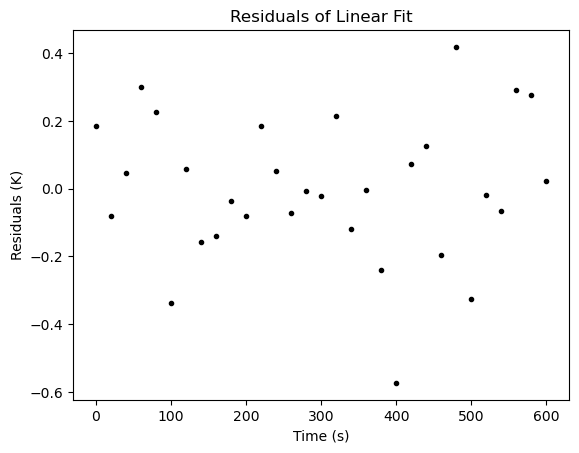

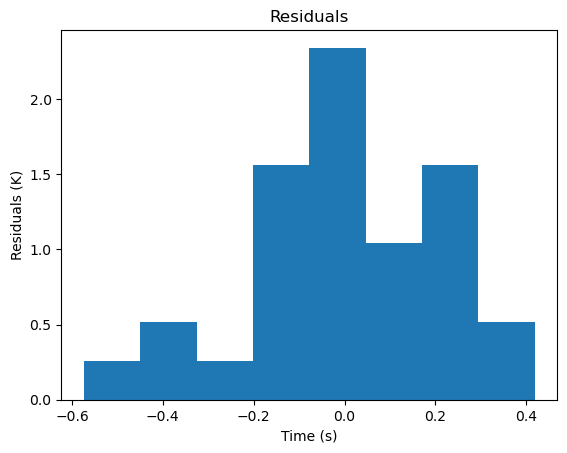

In [2]:
# Residual Analysis 

residuals = temperature - linear_fit(time, a, b)
plt.plot(time, residuals, "k.")
plt.xlabel("Time (s)")
plt.ylabel("Residuals (K)")
plt.title("Residuals of Linear Fit")
# plt.savefig("figures/residuals.png", dpi=450)
plt.show()

plt.hist(residuals,bins=8,density=True)
plt.xlabel("Time (s)")
plt.ylabel("Residuals (K)")
plt.title("Residuals")
plt.show()


In [3]:
# Uncertainties 
delta_U = 0.1       # voltage (V)
delta_R = 0.1       # resistance (Ohm)
delta_m = 0.001     # m (kg)
delta_P = P * np.sqrt((2*delta_U/U)**2 + (delta_R/R)**2) # power (watt)
delta_a = np.sqrt(pcov[0,0]) # slope 

delta_c = c * np.sqrt( (delta_P/P)**2 + (delta_m/m)**2 + (delta_a/a)**2 ) # full uncertainty propagation
print("Slope a =", a, "\u00B1", delta_a)
print("Power P =", P, "\u00B1", delta_P)
print("Specific heat c =", c, "\u00B1", delta_c, "J/kg·K")

# Agreement analysis 
c_lit = 4180 # J/kg*K
delta_c_lit = 0 # assume negligible 

delta = c - c_lit 
delta_total = np.sqrt(delta_c**2 + delta_c_lit**2)

z = np.abs(delta) / delta_total

print(f"Difference Δ = {delta:.2f} J/kg·K")
print(f"Combined uncertainty Δ_total = {delta_total:.2f} J/kg·K")
print(f"Z-value = {z:.2f}")

if z <= 1: 
    print("Result agrees well with literature value within uncertainty.") 
elif z <= 2: 
    print("Result agrees reasonably with literature value.") 
else: 
    print("Result does NOT agree with literature value.")

# Errorpercentage 
error_percent = np.abs(c - c_lit) / c_lit * 100
print(f"Percentage error = {error_percent:.2f} %")

Slope a = 0.011220161290322328 ± 0.00021674992196914236
Power P = 14.4 ± 0.27988569095257443
Specific heat c = 4278.013368791874 ± 118.09719468803871 J/kg·K
Difference Δ = 98.01 J/kg·K
Combined uncertainty Δ_total = 118.10 J/kg·K
Z-value = 0.83
Result agrees well with literature value within uncertainty.
Percentage error = 2.34 %


# Discussie en conclusie

De experimenteel bepaalde soortelijke warmte van water was 4278 ± 118 J/kg·K, wat dicht bij de literatuurwaarde van ongeveer 4180 J/kg·K ligt.
Het verschil van 98 J/kg·K is kleiner dan de gecombineerde onzekerheid en de Z-waarde van 0.83 toont aan dat de waarden goed overeenkomen.
Mogelijke foutbronnen zijn warmteverlies aan de omgeving, onvolledige menging van het water en onnauwkeurigheden in de metingen.
De lineaire fit was betrouwbaar, gezien de kleine onzekerheid op de helling en de consistente resultaten.
Dit betekent dat de gemeten waarde binnen de verwachtingen lag en dat de gebruikte methode redelijk nauwkeurig is, al zijn verbeteringen mogelijk.